# 01 · Exploratory Data Analysis
### Pfizer–Seagen Enterprise Risk Management — Group 10

**Purpose.** This notebook is the entry point of the analysis pipeline. Before any
qualitative scoring or quantitative modelling, it explores the underlying risk data:
the structure of the register, the distribution of likelihood and impact, how the two
relate, and the numeric inputs that feed the three risks selected for full quantitative
treatment.

**Data sources** (all loaded from Google Drive): `riskregister.csv` (the original 16-risk register), `Group10_M3_IW_DataSource.csv` (Indicators & Warning inputs), and `Group10_M3_MonteCarlo_Results.csv` (simulation summary).

**Pipeline position:** `eda.ipynb` → `qualitative_analysis.ipynb` → `quantitative_analysis.ipynb` → `monte_carlo.ipynb`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 70)

from pathlib import Path
def find_data(name):
    """Locate a data file whether run inside the repo or standalone."""
    for base in ["../data/raw", "../data/processed", "data/raw", ".", "/mnt/user-data/uploads"]:
        candidate = Path(base) / name
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not locate {name}")


def gdrive_csv(file_id, output):
    """Download a publicly-shared Google Drive file and return its local path.
    The file must be shared as 'Anyone with the link can view'. Uses gdown, which
    follows Drive's download-confirmation redirect; without it pandas may receive
    Drive's HTML warning/sign-in page and raise a ParserError."""
    try:
        import gdown
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown
    path = gdown.download(id=file_id, output=output, quiet=True)
    if path is None:
        raise RuntimeError(
            f"Drive download failed for {file_id}. "
            "Set the file's sharing to 'Anyone with the link can view'.")
    return path


## 1. Load the raw risk register (16 risks)
The project began with a 16-risk register scored on a 1–10 likelihood and impact scale. It is loaded here directly from Google Drive (the shared `riskregister.csv`).

In [2]:
# Raw 16-risk register — loaded from Google Drive
# Share link: https://drive.google.com/file/d/1g0teLbHuWSV9YBP8Oj6My0FD0MuWbPzJ/view?usp=sharing
raw = pd.read_csv(gdrive_csv("1g0teLbHuWSV9YBP8Oj6My0FD0MuWbPzJ", "riskregister.csv"),
                  encoding="utf-8-sig")
raw.columns = [c.strip() for c in raw.columns]
raw = raw.rename(columns={"Risk #": "RiskNo", "The Risk of/That": "Risk",
                          "Likelihood Score": "Likelihood", "Impact Score": "Impact"})
print(f"Raw register: {len(raw)} risks | columns: {list(raw.columns)}")
raw.head(6)

Raw register: 16 risks | columns: ['RiskNo', 'Risk', 'Likelihood', 'Impact']


,RiskNo,Risk,Likelihood,Impact
0,1,Interest coverage ratio falling below safe levels,7,9
1,2,Failure to achieve $10B Seagen 2030 revenue target,7,9
2,3,IRA Medicare drug-price negotiations compress Seagen ADC revenue,8,8
3,4,FDA Complete Response Letter (CRL) or labelling restriction on Sea...,6,7
4,5,Patent cliff and ADCETRIS biosimilar entry risk,6,8
5,6,Key ADC talent attrition from former Seagen organization,8,9


## 2. The expanded 20-risk register (analysis dataset)
Following instructor feedback that the register was sparse for a deal of this scale, four
risks were added — cybersecurity (R-017), ESG/workforce (R-018), payer concentration
(R-019) and FX exposure (R-020) — giving the **20-risk register** used throughout the rest
of the project. It is built here as the canonical dataset and written to `data/processed/`.

In [3]:

register_rows = [
 ("R-001","Interest coverage ratio falling below safe levels due to acquisition debt load","Financial",7,9,"High"),
 ("R-002","Failure to achieve $10B Seagen 2030 risk-adjusted revenue target","Financial",7,9,"High"),
 ("R-003","IRA Medicare drug-price negotiations compress Seagen ADC revenue","Legal/Reg.",8,8,"High"),
 ("R-004","FDA CRL or labelling restriction on Seagen pipeline ADC submissions","Legal/Reg.",6,7,"Medium"),
 ("R-005","Patent cliff and ADCETRIS biosimilar entry risk","Legal/Reg.",6,8,"Medium"),
 ("R-006","Key ADC talent attrition from former Seagen organization","Operational",8,9,"Critical"),
 ("R-007","ADC manufacturing scale-up failure at Seagen's Bothell facility","Operational",6,8,"Medium"),
 ("R-008","Clinical trial continuity disruption across Seagen's 30+ active INDs","Operational",5,7,"Medium"),
 ("R-009","IT systems and data harmonization cost overrun and timeline delay","Operational",5,6,"Medium"),
 ("R-010","ADC combination therapy first-mover opportunity (positive risk)","Strategic",7,8,"High"),
 ("R-011","Synergy realization shortfall against $1B target","Financial",6,7,"Medium"),
 ("R-012","Goodwill impairment and DCF value erosion","Financial",5,9,"Medium"),
 ("R-013","Free cash flow and dividend sustainability pressure","Financial",6,8,"Medium"),
 ("R-014","Antitrust post-close compliance and FTC ongoing scrutiny","Legal/Reg.",4,6,"Low"),
 ("R-015","Active litigation and ADC IP dispute risk","Legal/Reg.",5,8,"Medium"),
 ("R-016","R&D pipeline integration disruption across 60 combined programs","Operational",6,8,"Medium"),
 ("R-017","Cybersecurity breach or ransomware exposure during system integration","Technology",6,9,"High"),
 ("R-018","ESG and reputational risk from post-acquisition workforce reduction","Strategic",5,6,"Medium"),
 ("R-019","Payer and GPO concentration risk affecting ADC reimbursement","Financial",5,7,"Medium"),
 ("R-020","Foreign-exchange exposure on ex-US ADC revenue and trial costs","Financial",4,5,"Low"),
]
reg = pd.DataFrame(register_rows, columns=["RiskID","Risk","Category","Likelihood","Impact","Priority"])
reg["Score"] = reg["Likelihood"] * reg["Impact"]
reg["Added_in_revision"] = reg["RiskID"].isin(["R-017","R-018","R-019","R-020"])

import os
os.makedirs("../data/processed", exist_ok=True)
reg.to_csv("../data/processed/risk_register_20.csv", index=False)
print(f"Expanded register: {len(reg)} risks "
      f"({reg['Added_in_revision'].sum()} added in revision) -> saved to data/processed/risk_register_20.csv")
reg

Expanded register: 20 risks (4 added in revision) -> saved to data/processed/risk_register_20.csv


,RiskID,Risk,Category,Likelihood,Impact,Priority,Score,Added_in_revision
0,R-001,Interest coverage ratio falling below safe levels due to acquisiti...,Financial,7,9,High,63,False
1,R-002,Failure to achieve $10B Seagen 2030 risk-adjusted revenue target,Financial,7,9,High,63,False
2,R-003,IRA Medicare drug-price negotiations compress Seagen ADC revenue,Legal/Reg.,8,8,High,64,False
3,R-004,FDA CRL or labelling restriction on Seagen pipeline ADC submissions,Legal/Reg.,6,7,Medium,42,False
4,R-005,Patent cliff and ADCETRIS biosimilar entry risk,Legal/Reg.,6,8,Medium,48,False
5,R-006,Key ADC talent attrition from former Seagen organization,Operational,8,9,Critical,72,False
6,R-007,ADC manufacturing scale-up failure at Seagen's Bothell facility,Operational,6,8,Medium,48,False
7,R-008,Clinical trial continuity disruption across Seagen's 30+ active INDs,Operational,5,7,Medium,35,False
8,R-009,IT systems and data harmonization cost overrun and timeline delay,Operational,5,6,Medium,30,False
9,R-010,ADC combination therapy first-mover opportunity (positive risk),Strategic,7,8,High,56,False


## 3. Descriptive statistics

In [4]:
print("Category counts:")
print(reg["Category"].value_counts().to_string())
print("\nPriority counts:")
print(reg["Priority"].value_counts().reindex(["Critical","High","Medium","Low"]).to_string())
reg[["Likelihood","Impact","Score"]].describe().round(2)

Category counts:
Category
Financial      7
Legal/Reg.     5
Operational    5
Strategic      2
Technology     1

Priority counts:
Priority
Critical     1
High         5
Medium      12
Low          2


,Likelihood,Impact,Score
count,20.00,20.00,20.00
mean,5.85,7.60,45.35
std,1.14,1.19,14.02
min,4.00,5.00,20.00
25%,5.00,7.00,35.00
50%,6.00,8.00,46.50
75%,6.25,8.25,54.50
max,8.00,9.00,72.00


## 4. Distributions of likelihood, impact and score
The score distribution is the key one: it is right-skewed, meaning most risks are moderate
and a small tail carries the severe exposure.

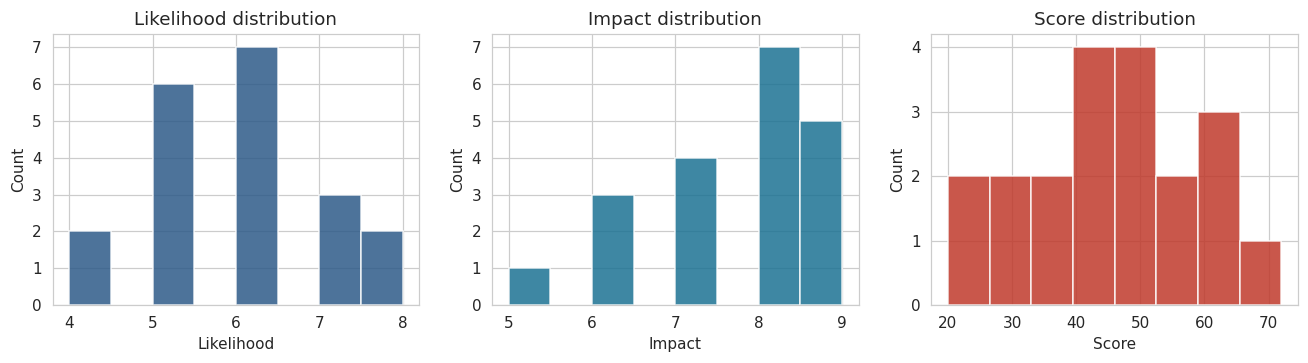

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, col, color in zip(axes, ["Likelihood", "Impact", "Score"], ["#2E5A88", "#1C7293", "#C0392B"]):
    ax.hist(reg[col], bins=8, color=color, alpha=0.85, edgecolor="white")
    ax.set_title(f"{col} distribution")
    ax.set_xlabel(col); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

## 5. Risks by category and by priority band

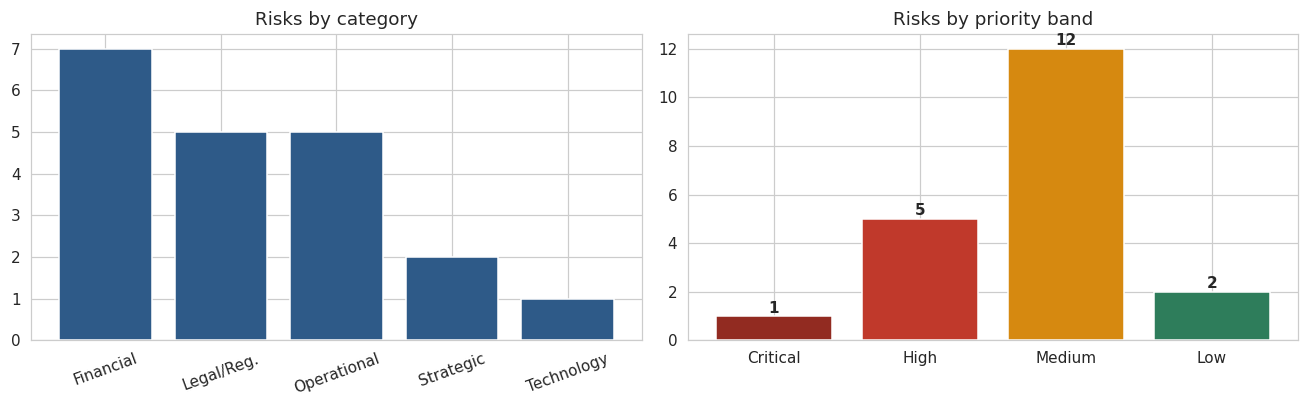

In [6]:
order = ["Critical", "High", "Medium", "Low"]
bandcol = {"Critical": "#922B21", "High": "#C0392B", "Medium": "#D68910", "Low": "#2E7D5B"}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
cc = reg["Category"].value_counts()
axes[0].bar(cc.index, cc.values, color="#2E5A88", edgecolor="white")
axes[0].set_title("Risks by category"); axes[0].tick_params(axis="x", rotation=20)
pc = reg["Priority"].value_counts().reindex(order)
axes[1].bar(pc.index, pc.values, color=[bandcol[p] for p in order], edgecolor="white")
for i, v in enumerate(pc.values):
    axes[1].text(i, v + 0.15, str(v), ha="center", fontweight="bold")
axes[1].set_title("Risks by priority band")
plt.tight_layout(); plt.show()

## 6. Likelihood vs Impact
Plotting the two scoring dimensions against each other shows where the register concentrates
and lets us see the priority bands as regions of the grid.

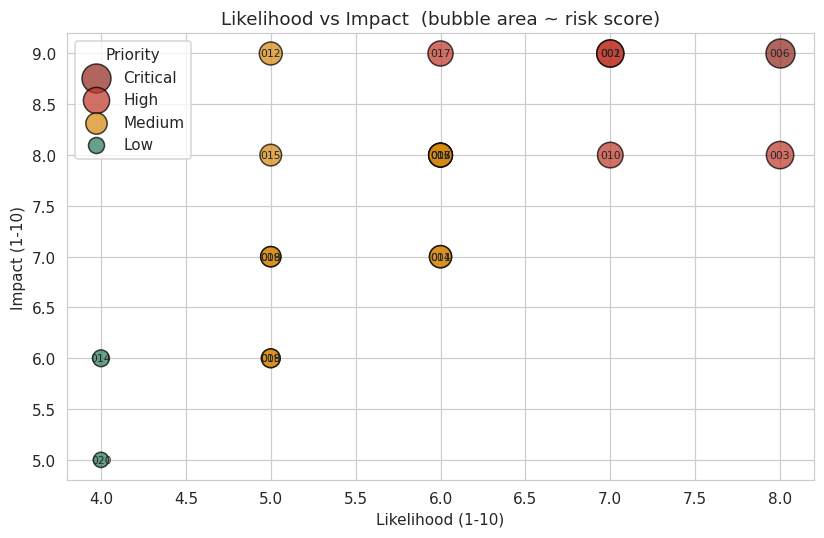

Pearson correlation, Likelihood vs Impact: r = 0.694


In [7]:
fig, ax = plt.subplots(figsize=(7.6, 5))
for pr in order:
    sub = reg[reg["Priority"] == pr]
    ax.scatter(sub["Likelihood"], sub["Impact"], s=sub["Score"] * 5,
               color=bandcol[pr], alpha=0.72, edgecolor="black", label=pr)
for _, r in reg.iterrows():
    ax.annotate(r["RiskID"].replace("R-", ""), (r["Likelihood"], r["Impact"]),
                fontsize=7, ha="center", va="center")
ax.set_xlabel("Likelihood (1-10)"); ax.set_ylabel("Impact (1-10)")
ax.set_title("Likelihood vs Impact  (bubble area ~ risk score)")
ax.legend(title="Priority"); plt.tight_layout(); plt.show()

r = reg["Likelihood"].corr(reg["Impact"])
print(f"Pearson correlation, Likelihood vs Impact: r = {r:.3f}")

## 7. Correlation between the scoring dimensions
Because Score is the product of Likelihood and Impact, it correlates with both by
construction; the more informative number is the modest Likelihood–Impact correlation,
which confirms the two dimensions carry partly independent information.

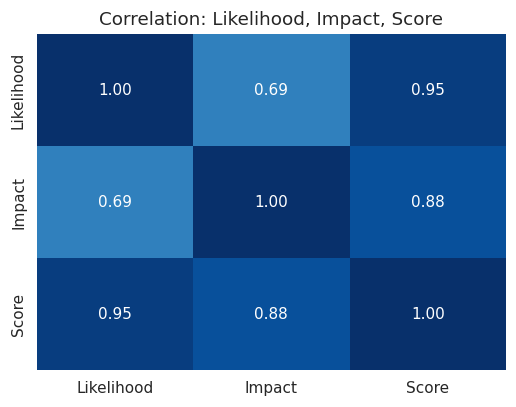

,Likelihood,Impact,Score
Likelihood,1.000,0.694,0.948
Impact,0.694,1.000,0.878
Score,0.948,0.878,1.000


In [8]:
corr = reg[["Likelihood", "Impact", "Score"]].corr()
fig, ax = plt.subplots(figsize=(4.8, 3.8))
sns.heatmap(corr, annot=True, cmap="Blues", vmin=0, vmax=1, fmt=".2f", ax=ax, cbar=False)
ax.set_title("Correlation: Likelihood, Impact, Score")
plt.tight_layout(); plt.show()
corr.round(3)

## 8. Inputs to the three quantified risks
Three risks are carried forward to full quantitative modelling: ADC market-share erosion
(R-MSE), critical talent poaching (R-006) and the combination-therapy opportunity (R-010).
Their Indicators & Warning inputs define the triangular probability and impact ranges used
by the Monte Carlo simulation.

In [14]:
# Indicators & Warning inputs — loaded from Google Drive
# Share link: https://drive.google.com/file/d/1wtPqodENlpdkJJgyt5psdWRfGWW6n6Bk/view?usp=sharing
iw = pd.read_csv(gdrive_csv("1wtPqodENlpdkJJgyt5psdWRfGWW6n6Bk", "Group10_M3_IW_DataSource.csv"))
cols = ["risk_id", "risk_name", "risk_type", "p_min", "p_mode", "p_max",
        "impact_min_Bn", "impact_mode_Bn", "impact_max_Bn"]
iw[cols]

,risk_id,risk_name,risk_type,p_min,p_mode,p_max,impact_min_Bn,impact_mode_Bn,impact_max_Bn
0,R-MSE,ADC market-share erosion,Threat,0.30,0.55,0.75,1.0,4.42,9.57
1,R-006,Critical ADC talent poaching,Threat,0.35,0.55,0.75,0.2,0.60,1.20
2,R-010,First-mover ADC combination advantage,Opportunity,0.30,0.50,0.70,1.0,1.50,2.50


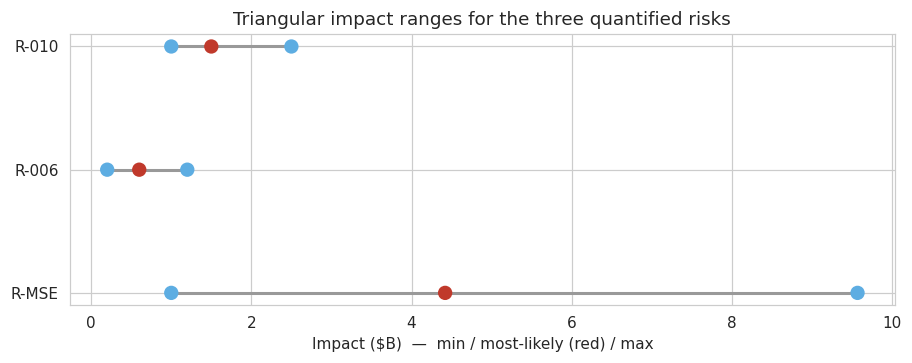

R-MSE has by far the widest impact range, foreshadowing the largest simulated dispersion.


In [15]:
fig, ax = plt.subplots(figsize=(8.4, 3.4))
for i, (_, r) in enumerate(iw.iterrows()):
    ax.plot([r.impact_min_Bn, r.impact_max_Bn], [i, i], color="#999", lw=2, zorder=1)
    ax.scatter([r.impact_min_Bn, r.impact_mode_Bn, r.impact_max_Bn], [i, i, i],
               color=["#5DADE2", "#C0392B", "#5DADE2"], s=70, zorder=2)
ax.set_yticks(range(len(iw))); ax.set_yticklabels(iw["risk_id"])
ax.set_xlabel("Impact ($B)  \u2014  min / most-likely (red) / max")
ax.set_title("Triangular impact ranges for the three quantified risks")
plt.tight_layout(); plt.show()
print("R-MSE has by far the widest impact range, foreshadowing the largest simulated dispersion.")

In [12]:
# Monte Carlo summary — loaded from Google Drive
# Share link: https://drive.google.com/file/d/1K4YNmV1ci6fXzHb_KFj7zhmXNCTyZGuk/view?usp=drive_link
mc = pd.read_csv(gdrive_csv("1K4YNmV1ci6fXzHb_KFj7zhmXNCTyZGuk", "Group10_M3_MonteCarlo_Results.csv"))
mc

,Risk ID,Risk,Type,Mean Probability,Impact P50 ($B),Impact P90 ($B),Expected Loss/Value mean ($B),EL P50 ($B),EL P90 ($B),Scenario VaR P90 ($B),Quant Likelihood (1-10)
0,R-MSE,ADC market-share erosion,Threat,0.533,4.86,7.48,2.66,2.55,4.13,6.67,5
1,R-006,Critical ADC talent poaching,Threat,0.550,0.65,0.95,0.37,0.35,0.54,0.87,5
2,R-010,First-mover ADC combination advantage,Opportunity,0.500,1.64,2.11,0.83,0.81,1.12,1.95,5


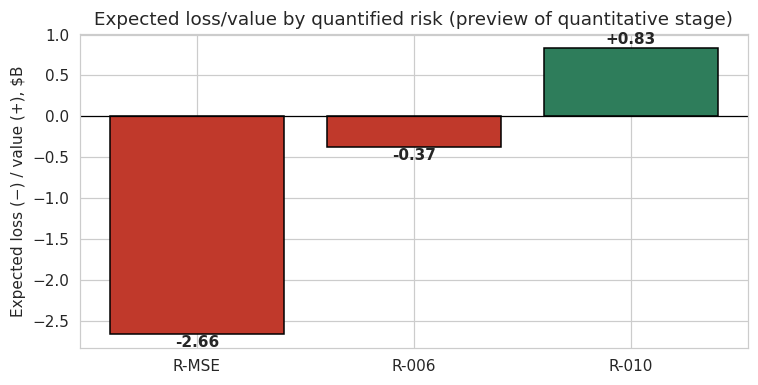

In [16]:
mc["EL_signed"] = mc.apply(
    lambda r: r["Expected Loss/Value mean ($B)"] * (-1 if r["Type"] == "Threat" else 1), axis=1)
fig, ax = plt.subplots(figsize=(7, 3.6))
colors = ["#C0392B" if t == "Threat" else "#2E7D5B" for t in mc["Type"]]
ax.bar(mc["Risk ID"], mc["EL_signed"], color=colors, edgecolor="black")
for i, v in enumerate(mc["EL_signed"]):
    ax.text(i, v + (0.05 if v >= 0 else -0.16), f"{v:+.2f}", ha="center", fontweight="bold")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Expected loss (\u2212) / value (+), $B")
ax.set_title("Expected loss/value by quantified risk (preview of quantitative stage)")
plt.tight_layout(); plt.show()

## 9. EDA takeaways
- The register is **right-skewed by severity**: 1 Critical and 5 High risks sit in a long tail above a body of Medium risks.
- Likelihood and Impact are only **moderately correlated**, so both dimensions add information — a risk can be high-impact but moderate-likelihood (e.g. R-012) or vice-versa.
- The severe risks **cluster in the Financial, Legal/Regulatory and competitive categories**, which is what motivates selecting competitive/financial risks for quantification.
- Among the three quantified risks, **R-MSE has the widest impact range** ($1.0B–$9.6B), which previews why it dominates the simulated dispersion — and why a single point estimate would be misleading.

These observations set up the qualitative assessment (`qualitative_analysis.ipynb`), where the scoring, severity bands and heatmap are formalised.